# Multiclass Car Classifier — Model Zoo Edition

Lab notebook for the whole project. **Implementations live in `.py` files** (`common/data.py`, `numpy_model/network.py`, later `tf_model/` and `sklearn_baseline/`). This notebook is the place you *run, plot, and check shapes*.

Run from the repo root so those imports work. Each phase is a section; later phases will reuse `load_dataset()` (cached after the first run).

| Phase | Status |
|---|---|
| 0 — data pipeline | in this notebook |
| 1 — NumPy forward pass | in this notebook |
| 2 — NumPy backprop | not yet |
| 3 — full training + diagnosis | not yet |
| 4 — TensorFlow | not yet |
| 5 — sklearn baseline | not yet |
| 6 — comparison & writeup | not yet |

---
# Phase 0 — Data pipeline

**Done when:** you can load a batch, print its shape, and it matches what you expect on paper.

The reusable pipeline is `common/data.py`. NumPy / Keras / sklearn will all import the same `load_dataset()` so they train on identical arrays.

Default preprocessing (PRD Section 2):
- resize to **64×64×3**
- flatten to a feature vector
- normalize pixels to **[0, 1]**
- **70 / 15 / 15** train / val / test, stratified by class

In [1]:
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from common.data import (
    CLASS_NAMES,
    FLAT_DIM,
    IMAGE_SIZE,
    N_CLASSES,
    RAW_DIR,
    load_batch,
    load_dataset,
)

print(f"IMAGE_SIZE = {IMAGE_SIZE}")
print(f"N_CLASSES  = {N_CLASSES}  {CLASS_NAMES}")
print(f"FLAT_DIM   = {IMAGE_SIZE} * {IMAGE_SIZE} * 3 = {FLAT_DIM}")

IMAGE_SIZE = 64
N_CLASSES  = 7  ('Convertible', 'Coupe', 'Hatchback', 'Pick-Up', 'SUV', 'Sedan', 'VAN')
FLAT_DIM   = 64 * 64 * 3 = 12288


## 0.1 What's on disk?

Kaggle already shipped `train/` / `valid/` / `test/` folders (~71 / 18.5 / 10.6). We **pool everything and re-split 70/15/15** so the split matches the PRD. `load_dataset(use_provided_splits=True)` keeps the original folders if you ever want that comparison.

In [2]:
print(f"raw dir: {RAW_DIR}\n")
print(f"{'class':12} {'train':>8} {'valid':>8} {'test':>8} {'total':>8}")
totals = Counter()
for split in ("train", "valid", "test"):
    for name in CLASS_NAMES:
        n = len(list((RAW_DIR / split / name).glob("*.jpg")))
        totals[(split, name)] = n

for name in CLASS_NAMES:
    tr, va, te = totals[("train", name)], totals[("valid", name)], totals[("test", name)]
    print(f"{name:12} {tr:8} {va:8} {te:8} {tr + va + te:8}")

n_total = sum(totals.values())
n_train = sum(totals[k] for k in totals if k[0] == "train")
n_valid = sum(totals[k] for k in totals if k[0] == "valid")
n_test = sum(totals[k] for k in totals if k[0] == "test")
print(f"{'TOTAL':12} {n_train:8} {n_valid:8} {n_test:8} {n_total:8}")
print(f"provided split ratios: {n_train / n_total:.1%} / {n_valid / n_total:.1%} / {n_test / n_total:.1%}")

raw dir: /Users/lokeshp/Projects/CarClassifier_ModelZoo/data/raw/Cars_Body_Type

class           train    valid     test    total
Convertible       811      292      174     1277
Coupe             721      106       79      906
Hatchback         701      176       99      976
Pick-Up           759      217      110     1086
SUV               847      274      125     1246
Sedan             729      170      109     1008
VAN               782      162      106     1050
TOTAL            5350     1397      802     7549
provided split ratios: 70.9% / 18.5% / 10.6%


## 0.2 Shapes on paper (before running the loader)

Raw images are almost all **different sizes**, so resize is not optional.

| Quantity | Expected shape |
|---|---|
| one resized image | `(64, 64, 3)` |
| one flattened image | `(12288,)` |
| `X_train` (~70% of 7549) | `(~5284, 12288)` |
| `y_train` | `(~5284,)` |
| `X_val` / `X_test` (~15% each) | `(~1132, 12288)` |
| a mini-batch of 32 | `(32, 12288)` and `(32,)` |

Pixel values after normalize: **float32 in [0, 1]**. Labels: **ints 0–6**.

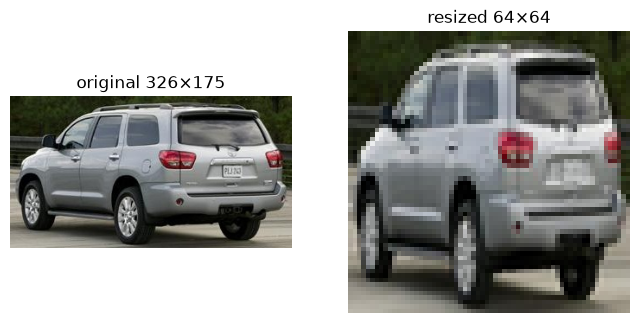

This is also the moment flattening starts to hurt: after flatten, the network
never sees that two pixels were neighbors — only a 12,288-long list of numbers.


In [3]:
sample_path = next((RAW_DIR / "train" / "SUV").glob("*.jpg"))
with Image.open(sample_path) as img:
    original = img.convert("RGB")
    resized = original.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.LANCZOS)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original)
axes[0].set_title(f"original {original.size[0]}×{original.size[1]}")
axes[0].axis("off")
axes[1].imshow(resized)
axes[1].set_title(f"resized {IMAGE_SIZE}×{IMAGE_SIZE}")
axes[1].axis("off")
plt.show()
print("This is also the moment flattening starts to hurt: after flatten, the network")
print("never sees that two pixels were neighbors — only a 12,288-long list of numbers.")

## 0.3 Run the pipeline

First run resizes all ~7.5k images and caches them under `data/processed/` (gitignored). Later runs load the cache.

In [4]:
data = load_dataset()  # 64x64, flatten, [0,1], 70/15/15 stratified

print("keys:", sorted(data.keys()))
print()
for split in ("train", "val", "test"):
    X, y = data[f"X_{split}"], data[f"y_{split}"]
    print(
        f"{split:5}  X {tuple(X.shape)}  y {tuple(y.shape)}  "
        f"dtype={X.dtype}  range=[{X.min():.3f}, {X.max():.3f}]"
    )

n = sum(data[f"y_{s}"].shape[0] for s in ("train", "val", "test"))
print(f"\ntotal examples: {n}")
print(f"paper check: X_train second dim == FLAT_DIM? {data['X_train'].shape[1] == FLAT_DIM}")
print(f"paper check: labels in 0..{N_CLASSES - 1}? "
      f"{data['y_train'].min()}..{data['y_train'].max()}")

keys: ['X_test', 'X_train', 'X_val', 'class_names', 'y_test', 'y_train', 'y_val']

train  X (5283, 12288)  y (5283,)  dtype=float32  range=[0.000, 1.000]
val    X (1133, 12288)  y (1133,)  dtype=float32  range=[0.000, 1.000]
test   X (1133, 12288)  y (1133,)  dtype=float32  range=[0.000, 1.000]

total examples: 7549
paper check: X_train second dim == FLAT_DIM? True
paper check: labels in 0..6? 0..6


## 0.4 Mini-batch + a few images reshaped back

If `(32, 12288)` prints below, Phase 0's "done when" is met.

batch X (32, 12288)  y (32,)
batch labels: [6 3 0 6 4 3 2 6 0 4] ...


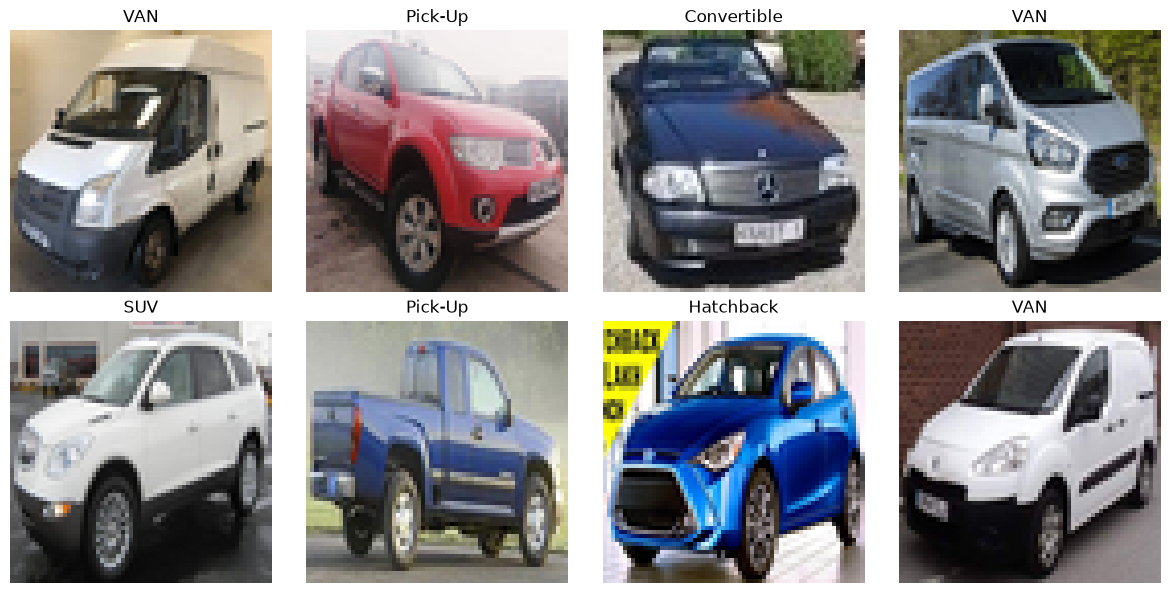

In [5]:
Xb, yb = load_batch(data["X_train"], data["y_train"], batch_size=32)
print(f"batch X {Xb.shape}  y {yb.shape}")
print(f"batch labels: {yb[:10]} ...")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.ravel(), range(8)):
    img = data["X_train"][i].reshape(IMAGE_SIZE, IMAGE_SIZE, 3)
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(CLASS_NAMES[int(data["y_train"][i])])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 0.5 Class balance after our split

Stratify should keep each class's share roughly constant across train/val/test. Coupe is the smallest class overall (~12%) — mild imbalance, not the optional skewed-data exercise yet.

train {'Convertible': 893, 'Coupe': 634, 'Hatchback': 683, 'Pick-Up': 760, 'SUV': 872, 'Sedan': 706, 'VAN': 735}
val   {'Convertible': 192, 'Coupe': 136, 'Hatchback': 147, 'Pick-Up': 163, 'SUV': 187, 'Sedan': 151, 'VAN': 157}
test  {'Convertible': 192, 'Coupe': 136, 'Hatchback': 146, 'Pick-Up': 163, 'SUV': 187, 'Sedan': 151, 'VAN': 158}


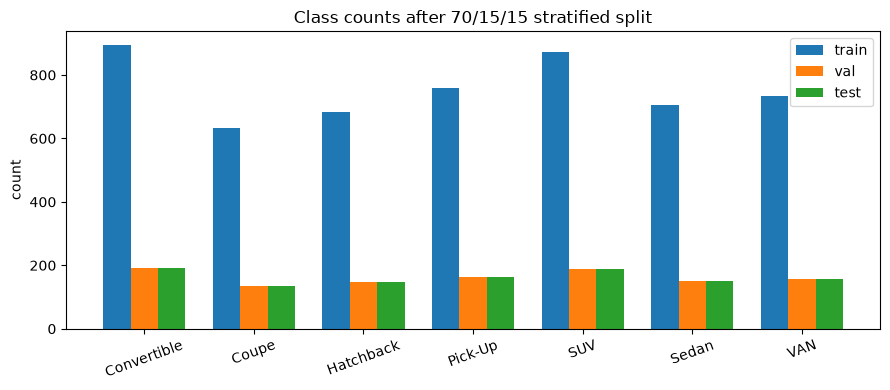

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(N_CLASSES)
width = 0.25
for i, split in enumerate(("train", "val", "test")):
    counts = np.bincount(data[f"y_{split}"], minlength=N_CLASSES)
    ax.bar(x + (i - 1) * width, counts, width, label=split)
    print(f"{split:5} {dict(zip(CLASS_NAMES, counts.tolist()))}")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20)
ax.set_ylabel("count")
ax.legend()
ax.set_title("Class counts after 70/15/15 stratified split")
plt.tight_layout()
plt.show()

---
# Phase 1 — NumPy forward pass only

No training. Random weights, one trip through the net, check two things:

1. Every matrix has the shape you predicted on paper.
2. Each row of the output is a probability distribution (sums to 1).

You implement `init_params`, `relu`, `softmax`, and `forward` in `numpy_model/network.py`. Cells below check that work.

If you already ran Phase 0 in this kernel, `data` is in memory. If not, the next cell loads it from cache.

In [7]:
from numpy_model.network import LAYER_DIMS, forward, init_params

print("LAYER_DIMS:", LAYER_DIMS)
print("read that as: input → hidden1 → hidden2 → output")

LAYER_DIMS: [12288, 128, 64, 7]
read that as: input → hidden1 → hidden2 → output


## 1.1 Shapes on paper

Batch of `m = 32` images. Convention: **rows = examples**, `Z = A @ W + b`.

| object | shape | why |
|---|---|---|
| `X` | `(32, 12288)` | 32 flattened 64×64×3 images |
| `W1` | `(12288, 128)` | maps 12288 features → 128 hidden units |
| `b1` | `(128,)` | one bias per hidden unit |
| `Z1`, `A1` | `(32, 128)` | 32 examples, 128 units |
| `W2` | `(128, 64)` | |
| `Z2`, `A2` | `(32, 64)` | |
| `W3` | `(64, 7)` | |
| `Z3`, `A3` | `(32, 7)` | 7 class scores / probabilities |

Rule: inner dimensions of a matmul must match. `(32, 12288) @ (12288, 128)` works; `(12288, 128) @ (32, 12288)` does not.

In [8]:
if "data" not in dir():
    data = load_dataset()

Xb, yb = load_batch(data["X_train"], data["y_train"], batch_size=32)
print(f"X batch {Xb.shape}  y batch {yb.shape}")

params = init_params()
for name, arr in params.items():
    print(f"{name:4} {arr.shape}")

X batch (32, 12288)  y batch (32,)
W1   (12288, 128)
b1   (128,)
W2   (128, 64)
b2   (64,)
W3   (64, 7)
b3   (7,)


In [9]:
A3, cache = forward(Xb, params)

print(f"A3 {A3.shape}   expected (32, 7)")
print(f"row sums (should be all ~1):\n{A3.sum(axis=1)}")
print(f"min={A3.min():.4f}  max={A3.max():.4f}   (should be in [0, 1])")
print(f"first example's 7 probs: {A3[0]}")
print(f"cache keys (stash intermediates for Phase 2): {sorted(cache.keys())}")

A3 (32, 7)   expected (32, 7)
row sums (should be all ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
min=0.0540  max=0.3047   (should be in [0, 1])
first example's 7 probs: [0.10996393 0.11249854 0.1655198  0.29182992 0.05728503 0.08262121
 0.18028156]
cache keys (stash intermediates for Phase 2): ['A1', 'A2', 'A3', 'Z1', 'Z2', 'Z3']


---
# Later phases

Phase 2+ will be added here as we get to them. Same notebook, new sections, math still in `.py` files.